# Topic 3 — Hands-On: Implementing Backpropagation From Scratch
## Building the Backward Pass, Step by Step

> **Objective:** In the theory session we learnt *why* backpropagation works (the chain rule) and traced it through a single neuron and a small network on paper. Now we will **implement it ourselves in code**, verify it's correct with gradient checking, and use it to actually train a network.

### What We Will Cover
1. **Coding** a single neuron's forward and backward pass
2. **Warming up** on the chain rule with a numeric exercise
3. **Building** reusable `forward_pass()` and `backward_pass()` functions for a 2-layer network
4. **Verifying** our backprop with **gradient checking**
5. **Training** a real network using only the functions we wrote ourselves
6. **Experimenting** — what happens to gradients as networks get deeper?

---
## 1. Setup — Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded!")

Libraries loaded!


---
## 2. Coding a Single Neuron's Forward and Backward Pass

Recall from the theory session:

```
Forward:   z = w*x + b,   a = ReLU(z)
Backward:  dLoss/dw = dLoss/dz * x
           dLoss/db = dLoss/dz
           dLoss/dx = dLoss/dz * w   (passed further back)
```

We'll write this as two small functions: `neuron_forward()` and `neuron_backward()`. The forward function saves a **cache** of the values the backward function will need — this avoids recomputing anything.

In [2]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def neuron_forward(x, w, b):
    """Forward pass through a single ReLU neuron.
    Returns the output `a`, plus a cache of values backward() will need."""
    z = np.dot(x, w) + b
    a = relu(z)
    cache = (x, w, z)
    return a, cache

def neuron_backward(dloss_da, cache):
    """Backward pass through a single ReLU neuron.
    dloss_da: how much the LOSS changes per unit change in this neuron's output `a`.
    Returns dLoss/dw, dLoss/db, and dLoss/dx (dLoss/dx is passed to earlier layers)."""
    x, w, z = cache
    da_dz = relu_derivative(z)
    dloss_dz = dloss_da * da_dz

    dloss_dw = dloss_dz * x
    dloss_db = dloss_dz
    dloss_dx = dloss_dz * w
    return dloss_dw, dloss_db, dloss_dx

# Test it on the same example from the theory session
x, w, b = 2.0, 0.6, 0.1
target = 3.0

a, cache = neuron_forward(x, w, b)
loss = (a - target) ** 2
dloss_da = 2 * (a - target)   # derivative of (a - target)^2 with respect to a

dloss_dw, dloss_db, dloss_dx = neuron_backward(dloss_da, cache)

print("Forward pass:")
print(f"  output a = {a}, loss = {loss:.4f}")
print("\nBackward pass (gradients computed by our function):")
print(f"  dLoss/dw = {dloss_dw:.4f}")
print(f"  dLoss/db = {dloss_db:.4f}")
print(f"  dLoss/dx = {dloss_dx:.4f}")
print("\nThese match the values we computed by hand in the theory session!")

Forward pass:
  output a = 1.3, loss = 2.8900

Backward pass (gradients computed by our function):
  dLoss/dw = -6.8000
  dLoss/db = -3.4000
  dLoss/dx = -2.0400

These match the values we computed by hand in the theory session!


---
## 3. Warm-Up: The Chain Rule on a New Example

Before scaling up to a full network, let's practice the chain rule on one more composite function: `y = (3x + 1)^3`.

We'll compute the derivative two ways — using the chain rule, and using **numerical differentiation** (nudge `x` slightly and see how much `y` changes) — and check that they agree.

In [3]:
# y = (3x + 1)^3
def g(x):
    u = 3 * x + 1
    y = u ** 3
    return y, u

x = 1.5
y, u = g(x)

# Chain rule: dy/du = 3u^2,  du/dx = 3   =>   dy/dx = 3u^2 * 3 = 9u^2
dy_du = 3 * u ** 2
du_dx = 3
dy_dx_chain_rule = dy_du * du_dx

# Numerical derivative, as a sanity check
epsilon = 1e-6
y_plus, _ = g(x + epsilon)
y_minus, _ = g(x - epsilon)
dy_dx_numerical = (y_plus - y_minus) / (2 * epsilon)

print(f"x = {x},  u = 3x + 1 = {u},  y = u^3 = {y}")
print(f"\nChain rule:  dy/dx = (dy/du)({dy_du}) x (du/dx)({du_dx}) = {dy_dx_chain_rule:.4f}")
print(f"Numerical:   dy/dx ~= {dy_dx_numerical:.4f}")
print(f"\nMatch? {np.isclose(dy_dx_chain_rule, dy_dx_numerical)}")
print("\nThis is the same trick we'll use throughout: whenever we're unsure if a gradient")
print("formula is right, we can always double-check it numerically.")

x = 1.5,  u = 3x + 1 = 5.5,  y = u^3 = 166.375

Chain rule:  dy/dx = (dy/du)(90.75) x (du/dx)(3) = 272.2500
Numerical:   dy/dx ~= 272.2500

Match? True

This is the same trick we'll use throughout: whenever we're unsure if a gradient
formula is right, we can always double-check it numerically.


---
## 4. Build a Dataset

Let's reuse the same two-class dataset from last session, so we can focus entirely on the backpropagation code this time.

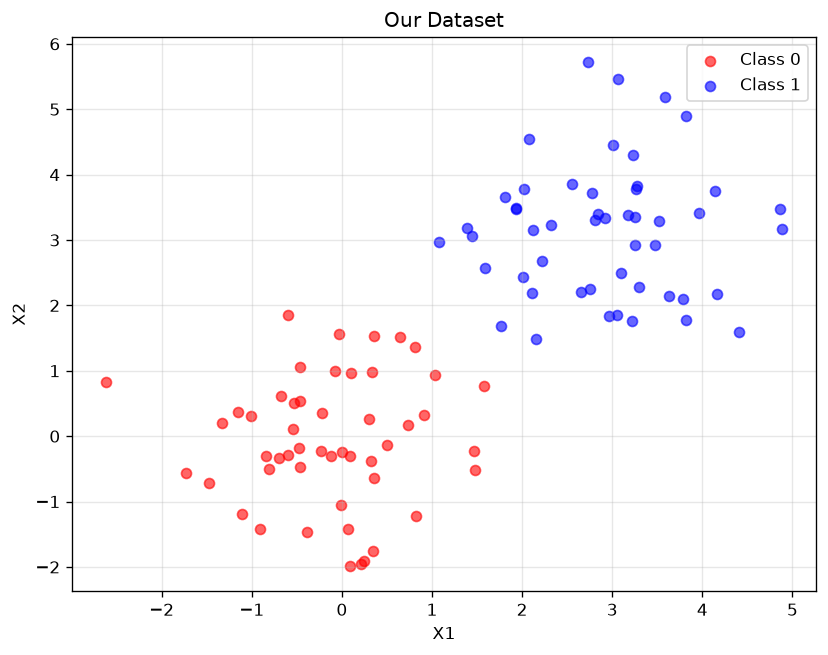

Total points: 100  (Class 0: 50, Class 1: 50)


In [4]:
np.random.seed(42)

class_0 = np.random.randn(50, 2) + np.array([0, 0])   # centered at (0, 0)
class_1 = np.random.randn(50, 2) + np.array([3, 3])   # centered at (3, 3)

X = np.vstack([class_0, class_1])
y = np.array([0]*50 + [1]*50).reshape(-1, 1)

plt.figure(figsize=(8, 6))
plt.scatter(class_0[:, 0], class_0[:, 1], c='red', label='Class 0', alpha=0.6)
plt.scatter(class_1[:, 0], class_1[:, 1], c='blue', label='Class 1', alpha=0.6)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Our Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total points: {len(X)}  (Class 0: {np.sum(y==0)}, Class 1: {np.sum(y==1)})")

---
## 5. Build Reusable `forward_pass()` and `backward_pass()` Functions

This time, instead of writing the forward/backward math inline inside the training loop, we'll wrap it into two clean functions:

- **`forward_pass()`** runs the data through the network and returns a `cache` of every intermediate value.
- **`backward_pass()`** takes that cache and the true labels, and returns the gradient for every weight and bias — this is the actual **backpropagation** step.

Network architecture: **2 inputs → hidden layer (ReLU) → 1 output (Sigmoid)**.

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Network architecture
input_size = 2
hidden_size = 10
output_size = 1

np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print("Network Architecture:")
print(f"- Input layer:  {input_size} neurons")
print(f"- Hidden layer: {hidden_size} neurons (ReLU)")
print(f"- Output layer: {output_size} neuron  (Sigmoid)")

Network Architecture:
- Input layer:  2 neurons
- Hidden layer: 10 neurons (ReLU)
- Output layer: 1 neuron  (Sigmoid)


In [6]:
def forward_pass(X, W1, b1, W2, b2):
    """Run the network forward. Returns the prediction `a2` and a
    cache of every intermediate value that backward_pass() will need."""
    z1 = X.dot(W1) + b1
    a1 = relu(z1)
    z2 = a1.dot(W2) + b2
    a2 = sigmoid(z2)
    cache = (X, z1, a1, z2, a2)
    return a2, cache


def backward_pass(y_true, W2, cache):
    """Backpropagate the loss gradient through both layers.
    Returns dLoss/dW1, dLoss/db1, dLoss/dW2, dLoss/db2."""
    X, z1, a1, z2, a2 = cache
    n = X.shape[0]

    # --- Output layer ---
    # For Sigmoid output + Binary Cross-Entropy loss, dLoss/dz2 simplifies to (a2 - y_true)
    dz2 = a2 - y_true
    dW2 = a1.T.dot(dz2) / n
    db2 = np.mean(dz2, axis=0, keepdims=True)

    # --- Hidden layer (reusing dz2, the output layer's error signal) ---
    da1 = dz2.dot(W2.T)
    dz1 = da1 * relu_derivative(z1)
    dW1 = X.T.dot(dz1) / n
    db1 = np.mean(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


def compute_loss(a2, y_true):
    """Binary cross-entropy loss."""
    epsilon = 1e-8
    return -np.mean(y_true * np.log(a2 + epsilon) + (1 - y_true) * np.log(1 - a2 + epsilon))


# Quick test: run one forward pass and one backward pass
a2, cache = forward_pass(X, W1, b1, W2, b2)
loss = compute_loss(a2, y)
dW1, db1, dW2, db2 = backward_pass(y, W2, cache)

print(f"Initial prediction (first 5): {a2[:5].ravel()}")
print(f"Initial loss: {loss:.4f}")
print(f"dW1 shape: {dW1.shape}, dW2 shape: {dW2.shape}")
print("\nOur forward_pass() and backward_pass() functions are working.")
print("Next, let's PROVE that backward_pass() is computing correct gradients.")

Initial prediction (first 5): [0.3705759  0.52621154 0.45982311 0.37433451 0.5       ]
Initial loss: 0.6530
dW1 shape: (2, 10), dW2 shape: (10, 1)

Our forward_pass() and backward_pass() functions are working.
Next, let's PROVE that backward_pass() is computing correct gradients.


---
## 6. Gradient Checking: Proving Our Backprop is Correct

Before trusting `backward_pass()` to train our network, let's verify it the same way we did in the theory session — by comparing each analytic gradient against a **numerical gradient** computed via finite differences.

We'll check every entry of `W1` this time, not just one.

In [7]:
print("Gradient check across every entry of W1:")
print("-" * 60)

dW1_analytic = dW1  # from the backward_pass() call above
epsilon = 1e-5
max_diff = 0

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W1_plus = W1.copy();  W1_plus[i, j] += epsilon
        W1_minus = W1.copy(); W1_minus[i, j] -= epsilon

        a2_plus, _ = forward_pass(X, W1_plus, b1, W2, b2)
        a2_minus, _ = forward_pass(X, W1_minus, b1, W2, b2)
        loss_plus = compute_loss(a2_plus, y)
        loss_minus = compute_loss(a2_minus, y)

        numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
        analytic_grad = dW1_analytic[i, j]
        diff = abs(numerical_grad - analytic_grad)
        max_diff = max(max_diff, diff)

print(f"Largest difference across all {W1.size} entries of W1: {max_diff:.10f}")

if max_diff < 1e-4:
    print("PASSED! Our backward_pass() function computes correct gradients.")
else:
    print("FAILED -- something is wrong in backward_pass().")

Gradient check across every entry of W1:
------------------------------------------------------------


Largest difference across all 20 entries of W1: 0.0000000122
PASSED! Our backward_pass() function computes correct gradients.


---
## 7. Train the Network Using Our Own Functions

Now that we trust `backward_pass()`, let's use it (together with `forward_pass()`) to actually train the network — the same **forward → loss → backward → update** loop from last session, but built entirely from the reusable functions we just wrote and verified.

In [8]:
# Re-initialize weights so we start training from scratch
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

learning_rate = 0.1
epochs = 200
losses, accuracies = [], []

print("Training the network...")
print("-" * 50)

for epoch in range(epochs):
    # Forward pass
    a2, cache = forward_pass(X, W1, b1, W2, b2)
    loss = compute_loss(a2, y)
    losses.append(loss)

    predictions = (a2 > 0.5).astype(int)
    accuracy = np.mean(predictions == y)
    accuracies.append(accuracy)

    # Backward pass (backpropagation)
    dW1, db1, dW2, db2 = backward_pass(y, W2, cache)

    # Update (gradient descent)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss:.4f} | Accuracy: {accuracy:.2%}")

print("\nTraining complete!")

Training the network...
--------------------------------------------------
Epoch  50/200 | Loss: 0.2051 | Accuracy: 95.00%
Epoch 100/200 | Loss: 0.1333 | Accuracy: 96.00%
Epoch 150/200 | Loss: 0.0981 | Accuracy: 97.00%
Epoch 200/200 | Loss: 0.0776 | Accuracy: 100.00%

Training complete!


---
## 8. Visualize Training Results

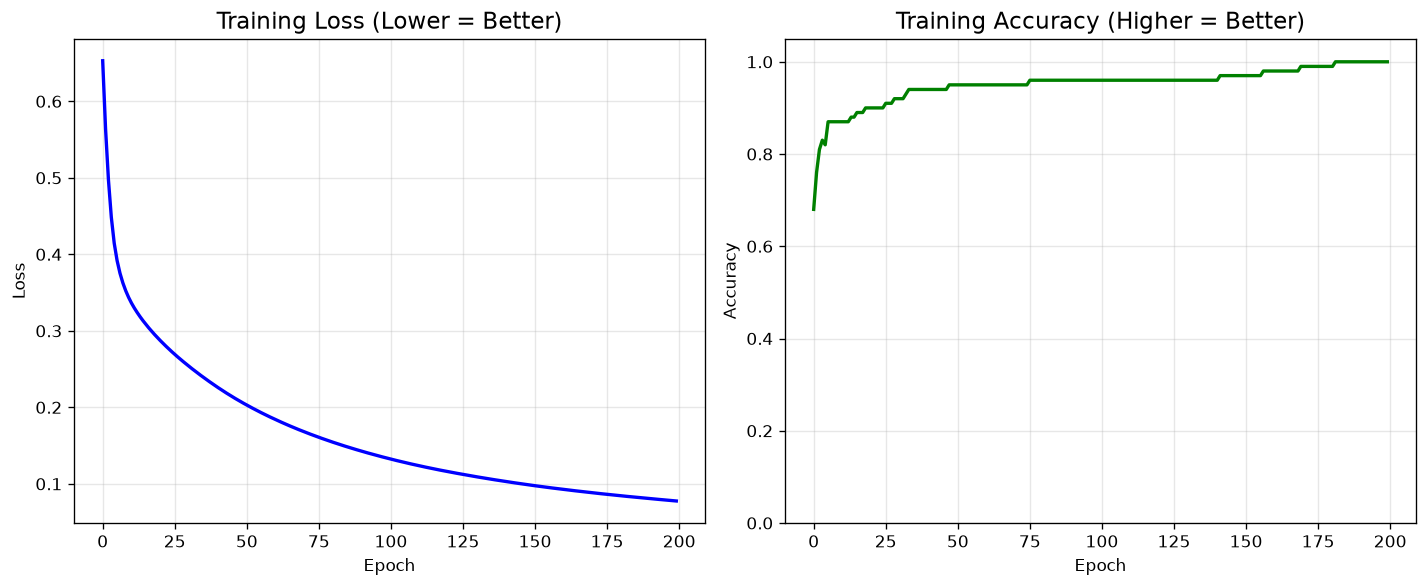

Final accuracy: 100.00%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Lower = Better)', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(accuracies, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy (Higher = Better)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"Final accuracy: {accuracies[-1]:.2%}")

---
## 9. Visualize the Decision Boundary

Let's confirm the network actually learned something meaningful by plotting the boundary it uses to separate the two classes.

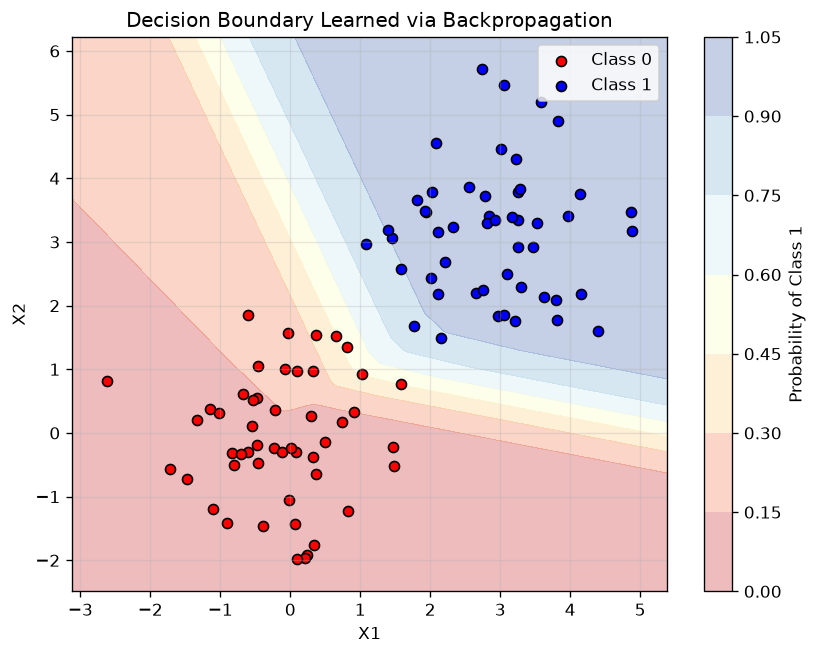

Backpropagation found the weights needed to correctly separate the two classes!


In [10]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z, _ = forward_pass(grid_points, W1, b1, W2, b2)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.colorbar(label='Probability of Class 1')
plt.scatter(class_0[:, 0], class_0[:, 1], c='red', label='Class 0', edgecolors='black')
plt.scatter(class_1[:, 0], class_1[:, 1], c='blue', label='Class 1', edgecolors='black')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Decision Boundary Learned via Backpropagation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Backpropagation found the weights needed to correctly separate the two classes!")

---
## 10. Experiment: What Happens to Gradients in Deeper Networks?

Backpropagation multiplies gradients together, layer after layer (that's the chain rule). Let's see what happens to the gradient's **magnitude** as it travels backward through a network with many layers, comparing **Sigmoid** hidden layers against **ReLU** hidden layers.

This is a preview of next session's topic: the **vanishing / exploding gradient problem**.

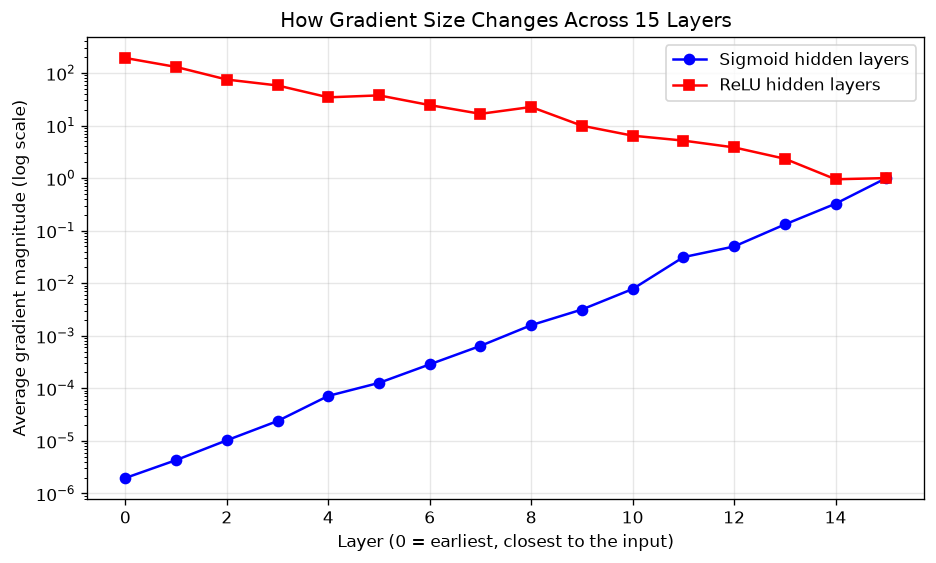

Gradient magnitude at the FIRST layer (closest to the input):
  Sigmoid network: 0.0000019672
  ReLU network:    192.573028

Gradient magnitude at the LAST layer (closest to the output): both start at 1.0

Observations:
- With Sigmoid, the gradient SHRINKS toward zero the further back it travels --
  this is the 'vanishing gradient' problem. Early layers barely learn.
- With ReLU, the gradient doesn't get squashed the same way, but it isn't
  automatically safe either -- depending on the weight scale, it can instead
  GROW uncontrollably ('exploding gradient').
- Managing this trade-off is exactly what next session's topic is about!


In [11]:
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def gradient_magnitude_per_layer(n_layers, layer_size, activation, activation_derivative, seed=0):
    """Forward-propagate through n_layers identical layers, then send a
    gradient of 1.0 backward from the output and record its size at every layer."""
    rng = np.random.RandomState(seed)
    x = rng.randn(1, layer_size)
    weights = [rng.randn(layer_size, layer_size) * 0.5 for _ in range(n_layers)]

    # Forward pass: keep every pre-activation z, since backward() needs it
    zs = []
    a = x
    for W in weights:
        z = a.dot(W)
        a = activation(z)
        zs.append(z)

    # Backward pass: start with gradient = 1.0 at the output and propagate it back
    grad = np.ones((1, layer_size))
    magnitudes = [np.mean(np.abs(grad))]
    for W, z in zip(reversed(weights), reversed(zs)):
        grad = (grad * activation_derivative(z)).dot(W.T)
        magnitudes.append(np.mean(np.abs(grad)))

    return magnitudes[::-1]  # earliest layer first, matching the order data flows forward


n_layers = 15
layer_size = 20

sigmoid_magnitudes = gradient_magnitude_per_layer(n_layers, layer_size, sigmoid, sigmoid_derivative)
relu_magnitudes = gradient_magnitude_per_layer(n_layers, layer_size, relu, relu_derivative)

plt.figure(figsize=(9, 5))
plt.semilogy(range(len(sigmoid_magnitudes)), sigmoid_magnitudes, 'o-', color='b', label='Sigmoid hidden layers')
plt.semilogy(range(len(relu_magnitudes)), relu_magnitudes, 's-', color='r', label='ReLU hidden layers')
plt.xlabel('Layer (0 = earliest, closest to the input)')
plt.ylabel('Average gradient magnitude (log scale)')
plt.title(f'How Gradient Size Changes Across {n_layers} Layers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Gradient magnitude at the FIRST layer (closest to the input):")
print(f"  Sigmoid network: {sigmoid_magnitudes[0]:.10f}")
print(f"  ReLU network:    {relu_magnitudes[0]:.6f}")
print(f"\nGradient magnitude at the LAST layer (closest to the output): both start at 1.0")

print("\nObservations:")
print("- With Sigmoid, the gradient SHRINKS toward zero the further back it travels --")
print("  this is the 'vanishing gradient' problem. Early layers barely learn.")
print("- With ReLU, the gradient doesn't get squashed the same way, but it isn't")
print("  automatically safe either -- depending on the weight scale, it can instead")
print("  GROW uncontrollably ('exploding gradient').")
print("- Managing this trade-off is exactly what next session's topic is about!")

---
## 11. Summary

### What We Built:
1. A **single neuron** with its own `forward()` and `backward()` functions
2. Reusable **`forward_pass()`** and **`backward_pass()`** functions for a full 2-layer network
3. A **gradient checker** that proves our backprop math is correct
4. A complete **training loop** that uses only the functions we wrote ourselves

### What We Explored:
- The **chain rule** connects a tiny local derivative to the network's overall loss
- **Gradient checking** is how real deep learning engineers catch bugs in backprop code
- Gradient **magnitude can shrink or grow** dramatically as it travels through many layers

### Key Takeaways:
1. Backpropagation = the chain rule applied systematically, layer by layer, back to front
2. Writing `forward_pass()` / `backward_pass()` as separate functions keeps training code clean and reusable
3. **Always gradient-check** a new backprop implementation before trusting it
4. Network depth interacts with the choice of activation function to affect how well gradients survive the journey backward — the seed of next session's vanishing/exploding gradient discussion